In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os


 ## Configuration

In [2]:
# Path configuration
VALIDATION_LABELS_PATH = 'yolo_dataset/labels/val'
PREDICTION_RESULTS_PATH = 'runs/detect/yolov8n_v8_5e_predict'
VALIDATION_RESULTS_PATH = 'runs/detect/yolov8n_v8_5e_val'

# Model configuration
CONFIDENCE_THRESHOLD = 0.5
CLASS_NAMES = ['pothole']

# Plot settings
plt.style.use('default')
sns.set_palette("husl")

 ## Helper Functions

In [3]:
def load_ground_truth_labels(label_dir):
    """Load ground truth labels dari file YOLO format"""
    gt_labels = []
    label_files = glob.glob(os.path.join(label_dir, '*.txt'))
    
    print(f"Ditemukan {len(label_files)} file label ground truth")
    
    for label_file in label_files:
        with open(label_file, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    gt_labels.append(class_id)
    
    print(f"Total ground truth potholes: {len(gt_labels)}")
    return gt_labels

In [4]:
def load_predicted_labels(pred_dir, confidence_threshold=0.5):
    """Load predicted labels dari hasil inference YOLOv8"""
    pred_labels = []
    pred_files = glob.glob(os.path.join(pred_dir, 'labels', '*.txt'))
    
    print(f"Ditemukan {len(pred_files)} file prediksi")
    
    for pred_file in pred_files:
        if os.path.getsize(pred_file) > 0:
            with open(pred_file, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 6:
                        class_id = int(parts[0])
                        confidence = float(parts[5])
                        if confidence >= confidence_threshold:
                            pred_labels.append(class_id)
    
    print(f"Total prediksi dengan confidence >= {confidence_threshold}: {len(pred_labels)}")
    return pred_labels

 ## Load Data

In [5]:
print("📁 Loading ground truth labels...")
gt_labels = load_ground_truth_labels(VALIDATION_LABELS_PATH)

print("\n📁 Loading predicted labels...")
pred_labels = load_predicted_labels(PREDICTION_RESULTS_PATH, CONFIDENCE_THRESHOLD)

📁 Loading ground truth labels...
Ditemukan 133 file label ground truth
Total ground truth potholes: 299

📁 Loading predicted labels...
Ditemukan 125 file prediksi
Total prediksi dengan confidence >= 0.5: 0


 ## Data Summary

In [ ]:
print("\n" + "="*50)
print("📊 DATA SUMMARY")
print("="*50)
print(f"Total Ground Truth Potholes: {len(gt_labels)}")
print(f"Total Predicted Potholes: {len(pred_labels)}")

if len(gt_labels) > 0:
    print("\nGround Truth Class Distribution:")
    unique_gt, counts_gt = np.unique(gt_labels, return_counts=True)
    for cls, count in zip(unique_gt, counts_gt):
        print(f"  Class {cls} (pothole): {count}")

if len(pred_labels) > 0:
    print("\nPredicted Class Distribution:")
    unique_pred, counts_pred = np.unique(pred_labels, return_counts=True)
    for cls, count in zip(unique_pred, counts_pred):
        print(f"  Class {cls} (pothole): {count}")


📊 DATA SUMMARY
Total Ground Truth Potholes: 299
Total Predicted Potholes: 0

Ground Truth Class Distribution:
  Class 0 (pothole): 299


 ## YOLOv8 Built-in Confusion Matrix

📊 YOLOv8 Built-in Confusion Matrix:


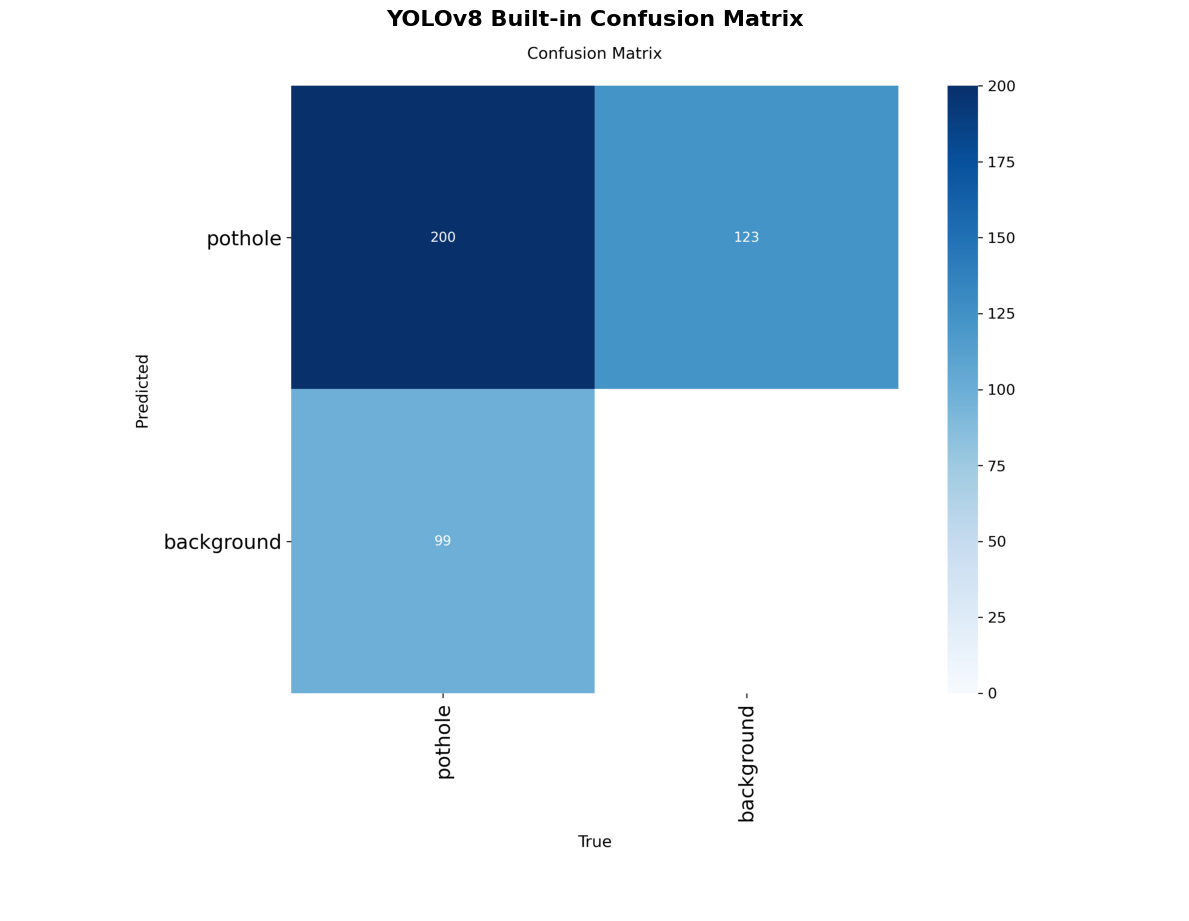

✅ Confusion matrix loaded from: runs/detect/yolov8n_v8_5e_val/confusion_matrix.png


In [ ]:
def show_yolo_confusion_matrix():
    """Tampilkan confusion matrix built-in dari YOLOv8"""
    cm_path = os.path.join(VALIDATION_RESULTS_PATH, 'confusion_matrix.png')
    
    if os.path.exists(cm_path):
        print("📊 YOLOv8 Built-in Confusion Matrix:")
        img = plt.imread(cm_path)
        
        plt.figure(figsize=(12, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title('YOLOv8 Built-in Confusion Matrix', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print(f"✅ Confusion matrix loaded from: {cm_path}")
    else:
        print(f"❌ YOLOv8 confusion matrix tidak ditemukan di: {cm_path}")
        print("💡 Pastikan sudah menjalankan validasi dengan mode=val")
        
        # List available files
        if os.path.exists(VALIDATION_RESULTS_PATH):
            available_files = os.listdir(VALIDATION_RESULTS_PATH)
            print("📁 File yang tersedia:")
            for file in available_files:
                print(f"   - {file}")

# Show YOLOv8's confusion matrix
show_yolo_confusion_matrix()